In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import mysql.connector

db = mysql.connector.connect(host = 'localhost',
                             username = 'root',
                             password = 'Rup@2002',
                             database = 'ecommerce')

cur = db.cursor()

# List all unique cities where customers are located.

In [19]:
query = """select distinct customer_city from customers"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data,columns = ['Unique Customer City'])
df

,Unique Customer City
0,franca
1,sao bernardo do campo
2,sao paulo
3,mogi das cruzes
4,campinas
...,...
4114,siriji
4115,natividade da serra
4116,monte bonito
4117,sao rafael


# Count the number of orders placed in 2017

In [41]:
query = """SELECT count(order_id) FROM orders where year(order_purchase_timestamp) = 2017"""

cur.execute(query)

data = cur.fetchall()
"Total number of orders placed in 2017",data[0][0]

('Total number of orders placed in 2017', 90202)

# Find the total sales per category

In [48]:
query = """SELECT product_category,round(sum(payment_value),2)
from products join order_items
	on products.product_id = order_items.product_id
join  payments
	on order_items.order_id = payments.order_id
group by product_category"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data,columns = ['Category','Sales'])
df

,Category,Sales
0,perfumery,1013477.32
1,Furniture Decoration,2860352.78
2,telephony,973764.10
3,bed table bath,3425107.34
4,automotive,1704588.66
...,...,...
69,cds music dvds,2398.86
70,La Cuisine,5827.06
71,Fashion Children's Clothing,1571.34
72,PC Gamer,4348.86


# Calculate the percentage of orders that were paid in installments

In [43]:
query = """select (sum(case when payment_installments >  0 then 1 else 0  end)/count(*))*100
from payments"""

cur.execute(query)

data = cur.fetchall()
"percentage of orders that were paid in installments",data[0][0]

('percentage of orders that were paid in installments', Decimal('99.9981'))

# Count the number of customers from each state

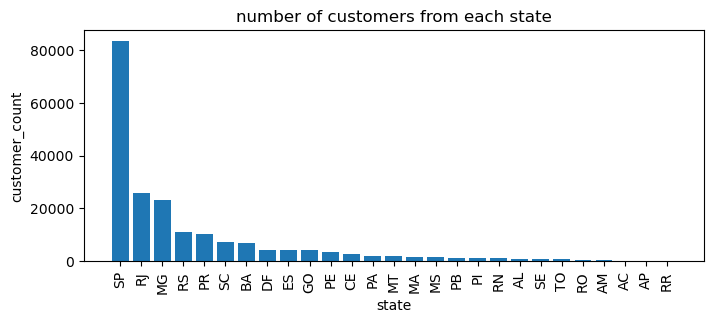

In [86]:
query = """select customer_state,count(customer_id) from customers group by customer_state"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data,columns = ['state','customer_count'])
df = df.sort_values(by = 'customer_count',ascending = False)

plt.figure(figsize = (8,3))
plt.bar(df['state'],df['customer_count'])
plt.xticks(rotation = 90)
plt.title('number of customers from each state')
plt.xlabel('state')
plt.ylabel('customer_count')
plt.show()


# Calculate the number of orders per month in 2018

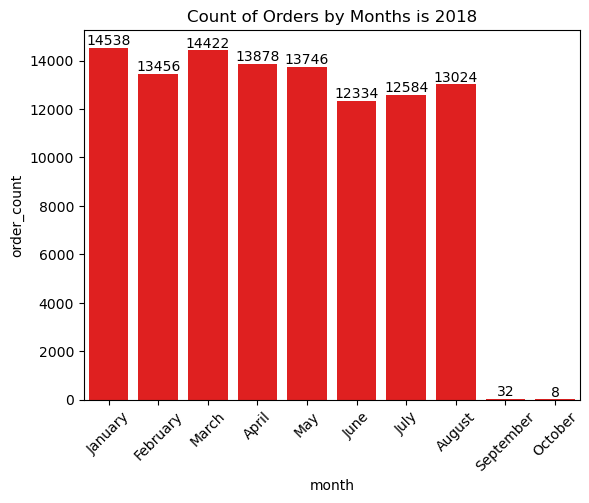

In [81]:
query = """SELECT monthname(order_purchase_timestamp) month,count(order_id) 
FROM orders where year(order_purchase_timestamp) = 2018 group by month"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data,columns = ['month','order_count'])
o = ["January", "February","March","April","May","June","July","August","September","October"]

ax = sns.barplot(x = df["month"],y =  df["order_count"], data = df, order = o, color = "red")
plt.xticks(rotation = 45)
ax.bar_label(ax.containers[0])
plt.title("Count of Orders by Months is 2018")
plt.show()

# Find the average number of products per order, grouped by customer city

In [88]:
query = """with count_per_order as (select orders.order_id,orders.customer_id,count(order_items.order_id) as oc
from orders join order_items
	on orders.order_id = order_items.order_id
group by orders.order_id,orders.customer_id
)
select customer_city,round(avg(count_per_order.oc),2) as average_orders
from customers join count_per_order
	on count_per_order.customer_id = customers.customer_id
group by customer_city order by average_orders desc"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data,columns = ['customer_city','avg_products/order'])
df

,customer_city,avg_products/order
0,padre carvalho,14.00
1,celso ramos,13.00
2,datas,12.00
3,candido godoi,12.00
4,matias olimpio,10.00
...,...,...
4105,tuiuti,2.00
4106,tibau do sul,2.00
4107,sao mamede,2.00
4108,sambaiba,2.00


# Calculate the percentage of total revenue contributed by each product category

In [91]:
query = """select upper(products.product_category) category, 
round((sum(payments.payment_value)/(select sum(payment_value) from payments))*100,2) sales_percentage
from products join order_items 
on products.product_id = order_items.product_id
join payments 
on payments.order_id = order_items.order_id
group by category order by sales_percentage desc"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data,columns = ['category','Percentage_distribution'])
df

,category,Percentage_distribution
0,BED TABLE BATH,21.40
1,HEALTH BEAUTY,20.71
2,COMPUTER ACCESSORIES,19.81
3,FURNITURE DECORATION,17.87
4,WATCHES PRESENT,17.86
...,...,...
69,PC GAMER,0.03
70,HOUSE COMFORT 2,0.02
71,CDS MUSIC DVDS,0.01
72,FASHION CHILDREN'S CLOTHING,0.01


# Identify the correlation between product price and the number of times a product has been purchased

In [100]:
query = """select products.product_category,count(order_items.product_id),round(avg(order_items.price),2)
from order_items join products
on order_items.product_id = products.product_id
group by products.product_category"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data,columns = ['category','count','price'])
df

arr1 = df['count']
arr2 = df['price']

corr = np.corrcoef([arr1,arr2])
"The correlation is",corr[0][-1]

('The correlation is', -0.10631514167157562)

# Calculate the total revenue generated by each seller, and rank them by revenue

In [103]:
query = """select seller_id,round(sum(payment_value),2) as total_revenue,rank() over(order by round(sum(payment_value),2) desc) as rn
from order_items join payments
on order_items.order_id = payments.order_id
group by seller_id"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data,columns = ['seller_id','total_revenue','rank'])
df

,seller_id,total_revenue,rank
0,7c67e1448b00f6e969d365cea6b010ab,507166.91,1
1,1025f0e2d44d7041d6cf58b6550e0bfa,308222.04,2
2,4a3ca9315b744ce9f8e9374361493884,301245.27,3
3,1f50f920176fa81dab994f9023523100,290253.42,4
4,53243585a1d6dc2643021fd1853d8905,284903.08,5
...,...,...,...
3090,ad14615bdd492b01b0d97922e87cb87f,19.21,3091
3091,702835e4b785b67a084280efca355756,18.56,3092
3092,4965a7002cca77301c82d3f91b82e1a9,16.36,3093
3093,77128dec4bec4878c37ab7d6169d6f26,15.22,3094


# Calculate the moving average of order values for each customer over their order history

In [108]:
query = """select orders.customer_id,orders.order_purchase_timestamp,avg(payments.payment_value)  
over(partition by orders.customer_id order by order_purchase_timestamp rows between 2 preceding and current row) as mov_avg
from orders join payments on orders.order_id = payments.order_id"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data,columns = ['customer_id','order_history','mov_avg'])
df

,customer_id,order_history,mov_avg
0,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.739998
1,00012a2ce6f8dcda20d059ce98491703,2017-11-14 16:08:26,114.739998
2,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.410004
3,000161a058600d5901f007fab4c27140,2017-07-16 09:40:32,67.410004
4,0001fd6190edaaf884bcaf3d49edf079,2017-02-28 11:06:43,195.419998
...,...,...,...
207767,ffff42319e9b2d713724ae527742af25,2018-06-13 16:57:05,214.130005
207768,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.500000
207769,ffffa3172527f765de70084a7e53aae8,2017-09-02 11:53:32,45.500000
207770,ffffe8b65bbe3087b653a978c870db99,2017-09-29 14:07:03,18.370001


# Calculate the cumulative sales per month for each year

In [115]:
query = """select years,months,sum(payment) over(order by years,months) as cum_sales  from
(select year(orders.order_purchase_timestamp) years,month(orders.order_purchase_timestamp) months,round(sum(payments.payment_value) ,2) as payment
from orders join payments on orders.order_id = payments.order_id
group by years,months order by years,months) as a"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data,columns = ['Year','Month','cumulative_sales'])
df

,Year,Month,cumulative_sales
0,2016,9,504.48
1,2016,10,118685.44
2,2016,12,118724.68
3,2017,1,395700.76
4,2017,2,979516.78
5,2017,3,1879243.98
6,2017,4,2714820.04
7,2017,5,3900657.68
8,2017,6,4923210.44
9,2017,7,6107976.28


# Calculate the year-over-year growth rate of total sales

In [5]:
query = """with year_sales as (select year(orders.order_purchase_timestamp) years,round(sum(payments.payment_value) ,2) as payment
from orders join payments on orders.order_id = payments.order_id group by years order by years)
select years,((payment - lag(payment,1) over(order by years))/lag(payment,1) over(order by years))* 100 as yoy_growth from year_sales"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data,columns = ['Year','yoy% growth'])
df

,Year,yoy% growth
0,2016,NaN
1,2017,12112.703761
2,2018,20.000924


# Calculate the retention rate of customers, defined as the percentage of customers who make another purchase within 6 months of their first purchase

In [17]:
 query = """with a as (select customers.customer_id,
min(orders.order_purchase_timestamp) first_order
from customers join orders
on customers.customer_id = orders.customer_id
group by customers.customer_id),

b as (select a.customer_id, count(distinct orders.order_purchase_timestamp) next_order
from a join orders
on orders.customer_id = a.customer_id
and orders.order_purchase_timestamp > first_order
and orders.order_purchase_timestamp < 
date_add(first_order, interval 6 month)
group by a.customer_id) 

select 100 * (count( distinct a.customer_id)/ count(distinct b.customer_id)) 
from a left join b 
on a.customer_id = b.customer_id ;"""

cur.execute(query)
data = cur.fetchall()

data

# It returns 'None' as we don't have any customer who purchase within 6 months.

[(None,)]

# Identify the top 3 customers who spent the most money in each year

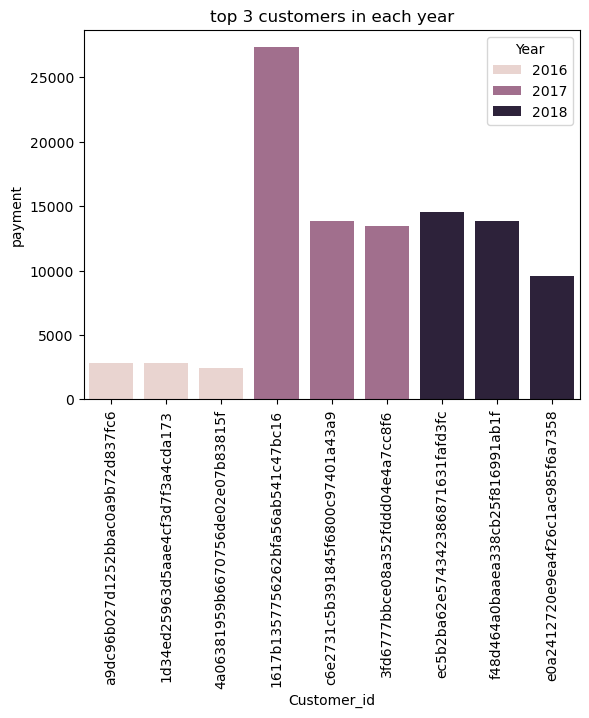

In [13]:
query = """with customer as (select customer_id,year(order_purchase_timestamp) years,sum(payment_value) payment,dense_rank()
over(partition by year(order_purchase_timestamp) order by sum(payment_value) desc) d_rank 
from orders join payments on orders.order_id = payments.order_id group by customer_id,years order by years)
select customer_id,years,payment,d_rank from customer where d_rank < 4"""

cur.execute(query)

data = cur.fetchall()

df = pd.DataFrame(data,columns = ['Customer_id','Year','payment','rank'])

sns.barplot(x = df['Customer_id'],y = df['payment'],data = df,hue = df['Year'])
plt.xticks(rotation = 90)
plt.title('top 3 customers in each year')
plt.show()